In [1]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator
from sklearn.metrics import confusion_matrix

# ----------------------------
# EDIT ONLY THESE IF NEEDED
# ----------------------------
LOG_ROOT = Path("/home/apaudel/NuGraph/logs")
SCRIPT_DIR = Path("/home/apaudel/NuGraph/scripts")

RUN_TPC  = "merged1_July3_tpc_only_ep45_bs64"
RUN_PDS  = "merged1_July3_tpc_pds_ep40_bs64"   # directory name may still say ep40

PRED_TPC = SCRIPT_DIR / "merged1_July3_tpc_only_ep45_bs64_test_predictions.h5"
PRED_PDS = SCRIPT_DIR / "merged1_July3_tpc_pds_ep40_bs64_test_predictions.h5"

OUTDIR = SCRIPT_DIR / "final_plots_tpc_vs_tpcpds"
OUTDIR.mkdir(parents=True, exist_ok=True)

print("Saving plots to:", OUTDIR)

# ----------------------------
# Helpers
# ----------------------------
def latest_version_dir(run_name):
    run_dir = LOG_ROOT / run_name
    versions = sorted(run_dir.glob("version_*"), key=lambda p: p.stat().st_mtime)
    if not versions:
        raise FileNotFoundError(f"No version_* found under {run_dir}")
    return versions[-1]

def load_event_accumulator(version_dir):
    ea = event_accumulator.EventAccumulator(
        str(version_dir),
        size_guidance={
            event_accumulator.SCALARS: 0,
            event_accumulator.IMAGES: 0,
        }
    )
    ea.Reload()
    return ea

def load_prediction_table(h5file):
    with h5py.File(h5file, "r") as f:
        table = f["events/table"][()]
    int_block = table["values_block_0"]
    prob_block = table["values_block_1"]
    # last two int columns are truth and prediction
    y_true = int_block[:, -2].astype(int)   # 0=ES, 1=CC
    y_pred = int_block[:, -1].astype(int)
    p_es   = prob_block[:, 0]
    p_cc   = prob_block[:, 1]
    return y_true, y_pred, p_es, p_cc

ver_tpc = latest_version_dir(RUN_TPC)
ver_pds = latest_version_dir(RUN_PDS)

print("TPC-only version :", ver_tpc)
print("TPC+PDS version  :", ver_pds)
print("TPC-only pred    :", PRED_TPC)
print("TPC+PDS pred     :", PRED_PDS)

ea_tpc = load_event_accumulator(ver_tpc)
ea_pds = load_event_accumulator(ver_pds)

ytrue_tpc, ypred_tpc, pes_tpc, pcc_tpc = load_prediction_table(PRED_TPC)
ytrue_pds, ypred_pds, pes_pds, pcc_pds = load_prediction_table(PRED_PDS)

print("Loaded everything successfully.")

Saving plots to: /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds
TPC-only version : /home/apaudel/NuGraph/logs/merged1_July3_tpc_only_ep45_bs64/version_0
TPC+PDS version  : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep40_bs64/version_0
TPC-only pred    : /home/apaudel/NuGraph/scripts/merged1_July3_tpc_only_ep45_bs64_test_predictions.h5
TPC+PDS pred     : /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep40_bs64_test_predictions.h5
Loaded everything successfully.


Common scalar tags to plot:
  event/loss-train
  event/loss-val
  loss/train
  loss/val
  lr-AdamW


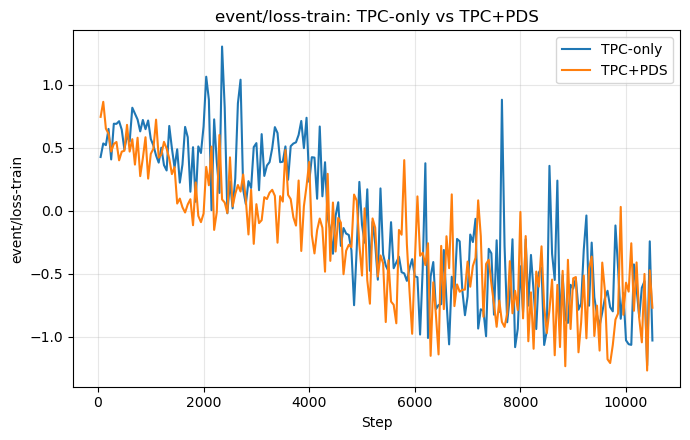

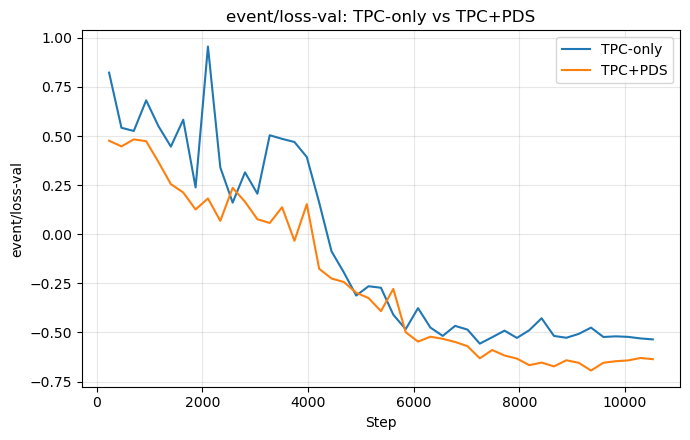

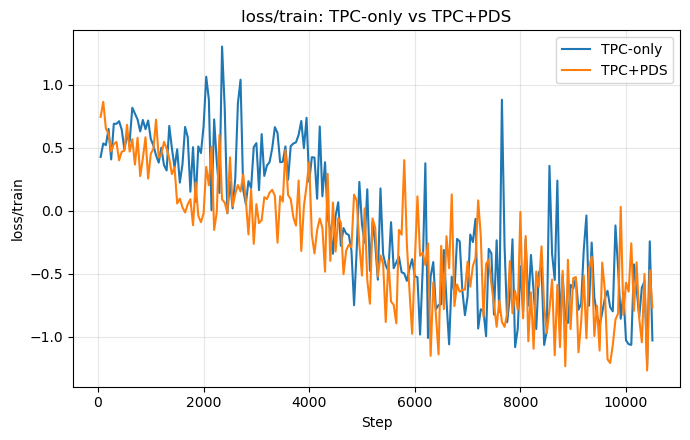

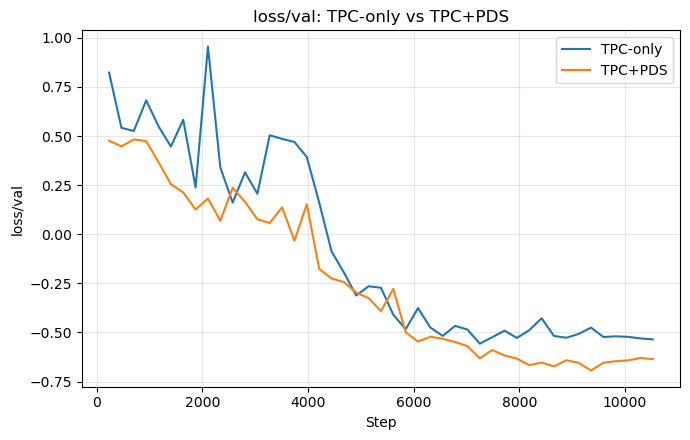

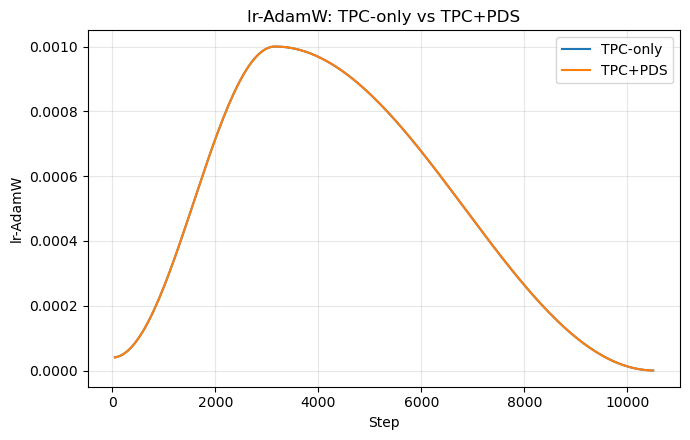


Saved scalar overlays:
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/event_loss-train_overlay.png
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/event_loss-val_overlay.png
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/loss_train_overlay.png
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/loss_val_overlay.png
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/lr-AdamW_overlay.png


In [2]:
def get_scalar_xy(ea, tag):
    events = ea.Scalars(tag)
    x = np.array([e.step for e in events])
    y = np.array([e.value for e in events])
    return x, y

tags_tpc = set(ea_tpc.Tags()["scalars"])
tags_pds = set(ea_pds.Tags()["scalars"])
common_tags = sorted(tags_tpc & tags_pds)

# Keep only useful tags
wanted = []
for t in common_tags:
    tl = t.lower()
    if any(k in tl for k in ["loss", "acc", "accuracy", "lr", "auc", "eff"]):
        wanted.append(t)

print("Common scalar tags to plot:")
for t in wanted:
    print(" ", t)

saved_scalar_plots = []

for tag in wanted:
    x1, y1 = get_scalar_xy(ea_tpc, tag)
    x2, y2 = get_scalar_xy(ea_pds, tag)

    plt.figure(figsize=(7, 4.5))
    plt.plot(x1, y1, label="TPC-only")
    plt.plot(x2, y2, label="TPC+PDS")
    plt.xlabel("Step")
    plt.ylabel(tag)
    plt.title(f"{tag}: TPC-only vs TPC+PDS")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    outpng = OUTDIR / f"{tag.replace('/','_')}_overlay.png"
    plt.savefig(outpng, dpi=150, bbox_inches="tight")
    saved_scalar_plots.append(outpng)
    plt.show()

print("\nSaved scalar overlays:")
for p in saved_scalar_plots:
    print(" ", p)


TPC-only Test Confusion Matrix — row-normalized
Counts:
 [[ 95 252]
 [408  80]]
Fractions:
 [[0.27377522 0.72622478]
 [0.83606557 0.16393443]]
Accuracy      = 0.7904
CC efficiency = 0.7262
ES efficiency = 0.8361


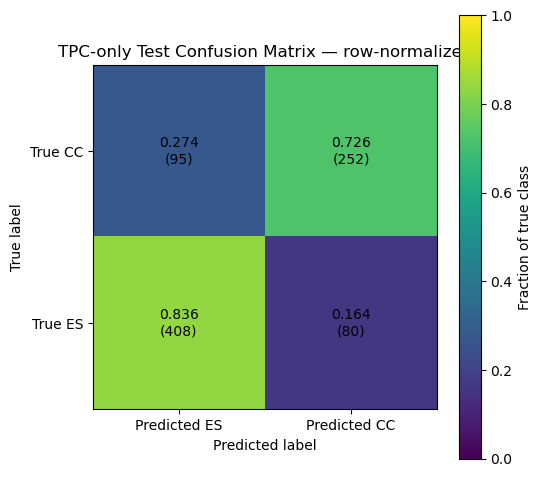


TPC+PDS Test Confusion Matrix — row-normalized
Counts:
 [[ 83 264]
 [415  73]]
Fractions:
 [[0.23919308 0.76080692]
 [0.85040984 0.14959016]]
Accuracy      = 0.8132
CC efficiency = 0.7608
ES efficiency = 0.8504


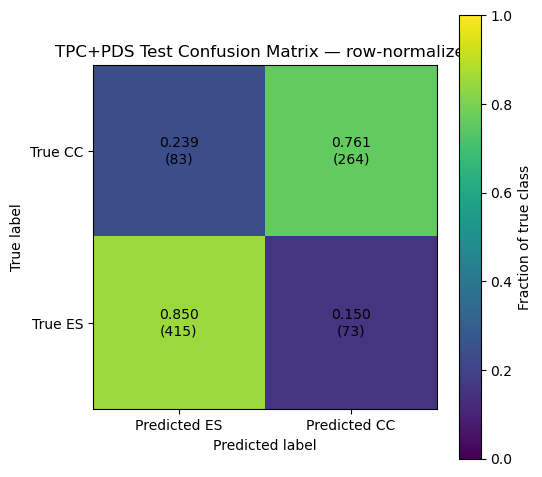


Saved:
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/confusion_matrix_tpc_only.png
  /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/confusion_matrix_tpc_pds.png


In [3]:
def build_cm_counts_custom(y_true, y_pred):
    # Y rows: True CC, True ES
    # X cols: Predicted ES, Predicted CC
    row_labels = [1, 0]   # CC, ES
    col_labels = [0, 1]   # ES, CC
    cm = np.zeros((2, 2), dtype=int)
    for i, t in enumerate(row_labels):
        for j, p in enumerate(col_labels):
            cm[i, j] = np.sum((y_true == t) & (y_pred == p))
    return cm

def plot_cm(y_true, y_pred, title, outpng):
    cm_counts = build_cm_counts_custom(y_true, y_pred)
    cm_frac = cm_counts / cm_counts.sum(axis=1, keepdims=True)

    acc = np.mean(y_true == y_pred)
    cc_eff = cm_frac[0, 1]   # top-right
    es_eff = cm_frac[1, 0]   # bottom-left

    print(f"\n{title}")
    print("Counts:\n", cm_counts)
    print("Fractions:\n", cm_frac)
    print(f"Accuracy      = {acc:.4f}")
    print(f"CC efficiency = {cc_eff:.4f}")
    print(f"ES efficiency = {es_eff:.4f}")

    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(cm_frac, vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted ES", "Predicted CC"])
    ax.set_yticklabels(["True CC", "True ES"])

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{cm_frac[i,j]:.3f}\n({cm_counts[i,j]})",
                    ha="center", va="center")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Fraction of true class")

    plt.tight_layout()
    plt.savefig(outpng, dpi=150, bbox_inches="tight")
    plt.show()

plot_cm(
    ytrue_tpc, ypred_tpc,
    "TPC-only Test Confusion Matrix — row-normalized",
    OUTDIR / "confusion_matrix_tpc_only.png"
)

plot_cm(
    ytrue_pds, ypred_pds,
    "TPC+PDS Test Confusion Matrix — row-normalized",
    OUTDIR / "confusion_matrix_tpc_pds.png"
)

print("\nSaved:")
print(" ", OUTDIR / "confusion_matrix_tpc_only.png")
print(" ", OUTDIR / "confusion_matrix_tpc_pds.png")

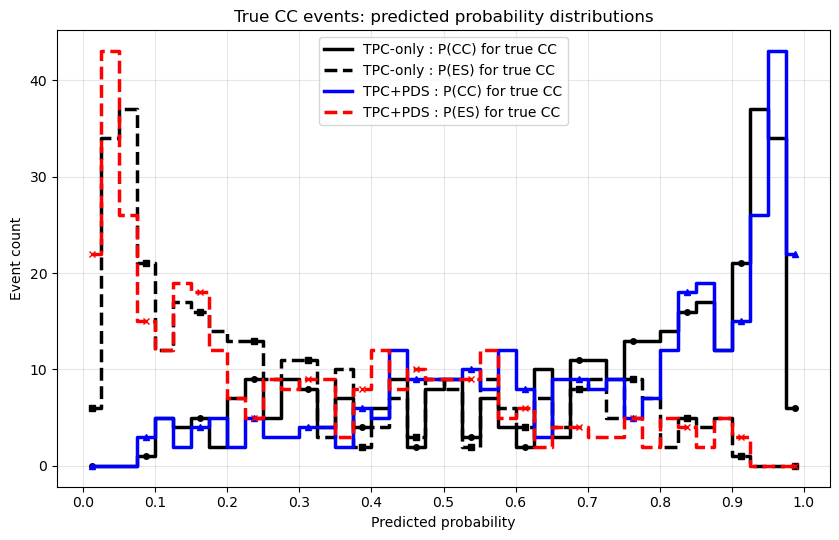

Saved: /home/apaudel/NuGraph/scripts/final_plots_tpc_vs_tpcpds/trueCC_probability_curves_tpc_vs_tpcpds_step.png


In [5]:
# Select only TRUE CC events
mask_tpc = (ytrue_tpc == 1)
mask_pds = (ytrue_pds == 1)

bins = np.linspace(0, 1, 41)   # 40 bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# TPC-only
hist_tpc_pcc, _ = np.histogram(pcc_tpc[mask_tpc], bins=bins)
hist_tpc_pes, _ = np.histogram(pes_tpc[mask_tpc], bins=bins)

# TPC+PDS
hist_pds_pcc, _ = np.histogram(pcc_pds[mask_pds], bins=bins)
hist_pds_pes, _ = np.histogram(pes_pds[mask_pds], bins=bins)

plt.figure(figsize=(8.5, 5.5))

# Step curves: better for histogram-style distributions
plt.step(
    bin_centers, hist_tpc_pcc, where="mid",
    color="black", linestyle="-", linewidth=2.5,
    label="TPC-only : P(CC) for true CC"
)
plt.plot(
    bin_centers, hist_tpc_pcc,
    color="black", linestyle="None", marker="o", markersize=4, markevery=3
)

plt.step(
    bin_centers, hist_tpc_pes, where="mid",
    color="black", linestyle="--", linewidth=2.5,
    label="TPC-only : P(ES) for true CC"
)
plt.plot(
    bin_centers, hist_tpc_pes,
    color="black", linestyle="None", marker="s", markersize=4, markevery=3
)

plt.step(
    bin_centers, hist_pds_pcc, where="mid",
    color="blue", linestyle="-", linewidth=2.5,
    label="TPC+PDS : P(CC) for true CC"
)
plt.plot(
    bin_centers, hist_pds_pcc,
    color="blue", linestyle="None", marker="^", markersize=4, markevery=3
)

plt.step(
    bin_centers, hist_pds_pes, where="mid",
    color="red", linestyle="--", linewidth=2.5,
    label="TPC+PDS : P(ES) for true CC"
)
plt.plot(
    bin_centers, hist_pds_pes,
    color="red", linestyle="None", marker="x", markersize=5, markevery=3
)

plt.xlabel("Predicted probability")
plt.ylabel("Event count")
plt.title("True CC events: predicted probability distributions")
plt.xticks(np.linspace(0, 1, 11))
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()

outpng = OUTDIR / "trueCC_probability_curves_tpc_vs_tpcpds_step.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", outpng)